 Loaded 3 results from exp8_all_data.json

--- AGGREGATED DATA ---
      galois_a  galois_f   optimal
All   0.299391  0.291220  0.347992
Geo   0.270406  0.265470  0.318718
Mov.  0.426266  0.319428  0.436496
Wor.  0.201502  0.288763  0.288763


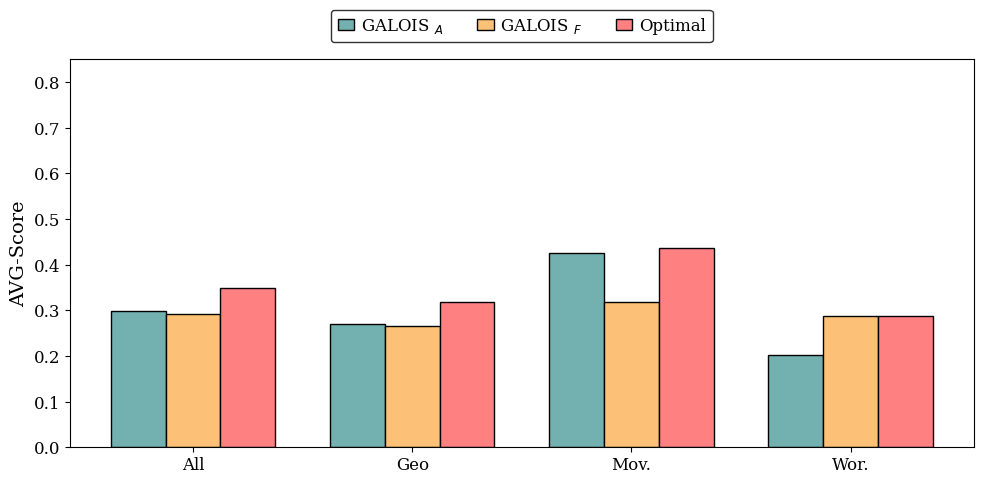

In [1]:
# python
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# --- DATA LOADING ---
json_file = "exp8_all_data.json"

if not os.path.exists(json_file):
    print(f" ATTENTION: File '{json_file}' not found.")
    # Dummy data to test the plot if the file is missing
    data = [
        {"dataset": "GEO", "galois_a": 0.633, "galois_f": 0.640, "optimal": 0.702},
        {"dataset": "MOVIES", "galois_a": 0.632, "galois_f": 0.640, "optimal": 0.680},
        {"dataset": "WORLD", "galois_a": 0.352, "galois_f": 0.454, "optimal": 0.454},
        # Add more if needed...
    ]
else:
    with open(json_file, "r") as f:
        raw_data = json.load(f)
    print(f" Loaded {len(raw_data)} results from {json_file}")
    data = raw_data

# DATA PROCESSING (Aggregation per Dataset) ---
df = pd.DataFrame(data)

# Group by dataset and compute the mean
df_grouped = df.groupby("dataset")[["galois_a", "galois_f", "optimal"]].mean()

# Compute the global "ALL" mean (mean of all queries, not mean of means)
all_means = df[["galois_a", "galois_f", "optimal"]].mean()
# Add the "ALL" row to the dataframe
df_grouped.loc["ALL"] = all_means

# Custom order for the plot (as in the paper)
# Place ALL first, then the others alphabetically or specific order
custom_order = ["ALL", "FLIGHT", "PRESIDENTS", "GEO", "MOVIES", "WORLD"]
# Keep only those present in your data
final_order = [d for d in custom_order if d in df_grouped.index]
# Append any extra datasets at the end
for d in df_grouped.index:
    if d not in final_order:
        final_order.append(d)

df_final = df_grouped.loc[final_order]

# Rename for the plot (e.g., GEO -> Geo., ALL -> All)
labels_map = {
    "ALL": "All",
    "FLIGHT": "Fli.",
    "PRESIDENTS": "Pres.",
    "GEO": "Geo",
    "MOVIES": "Mov.",
    "WORLD": "Wor."
}
df_final.index = [labels_map.get(idx, idx) for idx in df_final.index]

print("\n--- AGGREGATED DATA ---")
print(df_final)

# --- 3. PLOT CREATION ---
# Style settings
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12

# Colors similar to the paper (Aqua green, Orange, Red)
colors = ['#73B0B0', '#FDC077', '#FF8080']
edge_color = 'black'

# Dimensions
n_groups = len(df_final)
bar_width = 0.25
indices = np.arange(n_groups)

fig, ax = plt.subplots(figsize=(10, 5),  facecolor='white')

# Plot the 3 bars
# GALOIS A
rects1 = ax.bar(indices - bar_width, df_final["galois_a"], bar_width,
                label=r'GALOIS $_A$', color=colors[0], edgecolor=edge_color, linewidth=1)

# GALOIS F
rects2 = ax.bar(indices, df_final["galois_f"], bar_width,
                label=r'GALOIS $_F$', color=colors[1], edgecolor=edge_color, linewidth=1)

# OPTIMAL
rects3 = ax.bar(indices + bar_width, df_final["optimal"], bar_width,
                label='Optimal', color=colors[2], edgecolor=edge_color, linewidth=1)

# --- 4. FORMATTING ---
ax.set_ylabel('AVG-Score', fontsize=14)
ax.set_xticks(indices)
ax.set_xticklabels(df_final.index, fontsize=12)
ax.set_ylim(0, 0.85)  # Y-axis max a bit above the max (0.8)

# Legend centered at the top
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15),
          ncol=3, frameon=True, edgecolor='black', handlelength=1.0, handletextpad=0.4)


# Function to add values above/inside bars (optional, vertical as in the paper)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        # Text rotated 90 degrees inside the bar
        ax.text(rect.get_x() + rect.get_width() / 2., height - 0.05,
                f'{height:.3f}',
                ha='center', va='top', rotation=90, color='white', fontsize=10, fontweight='bold')


# Uncomment if you want numbers inside the bars (as in some versions)
# autolabel(rects1)
# autolabel(rects2)
# autolabel(rects3)

plt.tight_layout()
plt.show()
